# 多分类支持向量机(SVM)底层实现
## 实验内容
1. 从零实现SVM合页损失函数，包含朴素循环版与纯向量化优化版；
2. 手动推导并实现解析梯度，通过数值梯度校验实现正确性；
3. 基于小批量SGD完成模型训练，在验证集上完成学习率、正则化强度超参寻优；
4. 可视化训练得到的分类权重，直观理解模型特征学习效果。

In [21]:
# 准备工作

import random
import numpy as np
from datasets.data_utils import load_CIFAR10
import matplotlib.pyplot as plt
from pylab import mpl
mpl.rcParams['font.sans-serif'] = ['SimHei']
from __future__ import print_function

# 让matplotlib图显示在 notebook，不要另外打开一个窗口
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # 默认的绘图大小
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# 自动加载模型
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 加载CIFAR-10数据及预处理

In [22]:
# 加载 CIFAR-10 原始数据.
cifar10_dir = '../datasets/cifar-10-batches-py'

# 清除变量，防止多次加载数据(耗内存)
try:
   del X_train, y_train
   del X_test, y_test
   print('清除先前加载的数据')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# 打印训练、测试数据的现状，看看是否合理
print('训练数据 shape: ', X_train.shape)
print('训练标签 shape: ', y_train.shape)
print('测试数据 shape: ', X_test.shape)
print('测试标签 shape: ', y_test.shape)

清除先前加载的数据
训练数据 shape:  (50000, 32, 32, 3)
训练标签 shape:  (50000,)
测试数据 shape:  (10000, 32, 32, 3)
测试标签 shape:  (10000,)


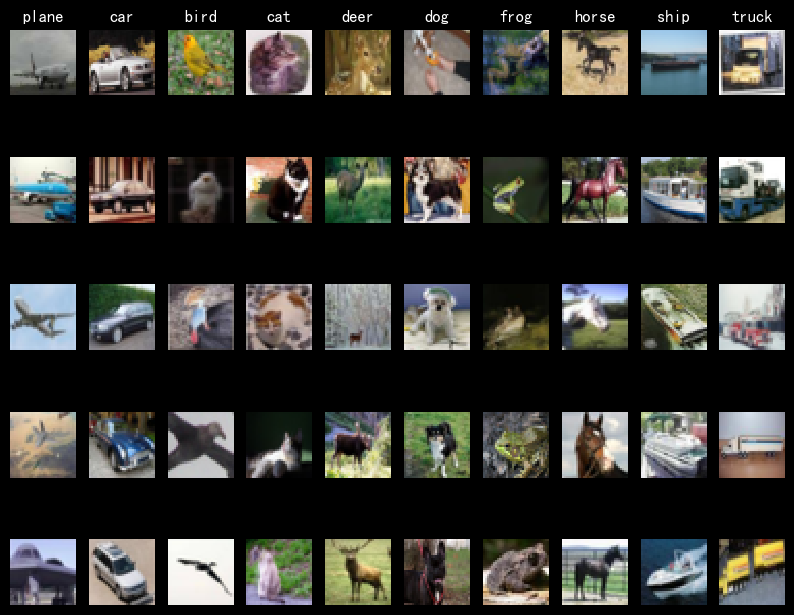

In [23]:
# 可视化部分样本数据，每个分类显示一小部分图片
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 5
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [24]:
# 将数据拆分为训练、验证、测试集。还拿出500个样本用于开发测试，用于快速运行，验证代码。
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# 验证集
mask = range(num_training, num_training + num_validation)
# 按索引截取验证集，range索引内存效率更高
X_val = X_train[mask]
y_val = y_train[mask]

# 训练集
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# 从训练集中拿出一小部分用于开发测试
mask = np.random.choice(num_training, num_dev, replace=False)  # np.random.choice：返回的是一个 NumPy 整数数组，这也是一种合法的 “整数数组索引”
X_dev = X_train[mask]
y_dev = y_train[mask]

# 测试集
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('训练数据 shape: ', X_train.shape)
print('训练标签 shape: ', y_train.shape)
print('验证数据 shape: ', X_val.shape)
print('验证标签 shape: ', y_val.shape)
print('测试数据 shape: ', X_test.shape)
print('测试标签 shape: ', y_test.shape)
print('开发数据 shape: ', X_dev.shape)
print('开发标签 shape: ', y_dev.shape)

训练数据 shape:  (49000, 32, 32, 3)
训练标签 shape:  (49000,)
验证数据 shape:  (1000, 32, 32, 3)
验证标签 shape:  (1000,)
测试数据 shape:  (1000, 32, 32, 3)
测试标签 shape:  (1000,)
开发数据 shape:  (500, 32, 32, 3)
开发标签 shape:  (500,)


In [25]:
# 图片特征展平为一维向量
X_train = X_train.reshape((X_train.shape[0], -1))
X_val = X_val.reshape((X_val.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))
X_dev = X_dev.reshape((X_dev.shape[0], -1))

# 输出维度校验
print('               (样本数, 像素总值)')
print('训练数据 shape: ', X_train.shape)
print('验证数据 shape: ', X_val.shape)
print('测试数据 shape: ', X_test.shape)
print('开发数据 shape: ', X_dev.shape)

               (样本数, 像素总值)
训练数据 shape:  (49000, 3072)
验证数据 shape:  (1000, 3072)
测试数据 shape:  (1000, 3072)
开发数据 shape:  (500, 3072)


(3072,)
[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


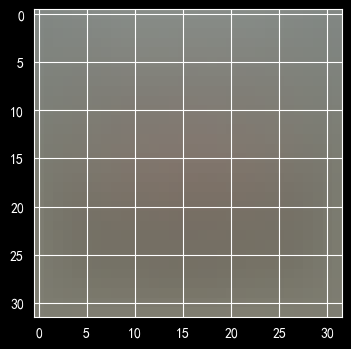

In [26]:
# 数据预处理: 减掉平均图像
# 用训练集算出 mean_image，再从每张图片里减掉它，相当于把所有图片的 “基准亮度” 对齐到 0, 这样做可以让后续的 SVM 权重学习到 “偏离平均的特征”，而不是被整体亮度主导，有助于模型收敛和性能提升

# 首先: 计算训练集像素均值
mean_image = np.mean(X_train, axis=0)  # axis=0：跳过样本维度（把所有样本的同一像素值加起来），只保留像素维度，计算每个像素的平均值
#打印一小部分样本
print(mean_image.shape)   # mean_image 是一个一维数组，长度为 3072
print(mean_image[:10]) 
plt.figure(figsize=(4,4)) # 创建宽4英寸,高4英寸的画布 (英寸物理距离)
# 可视化平均图像
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # uint8: 0~255的无符号整数，是图像的标准存储类型. 图像处理时（比如算均值）会转成浮点数保证精度，显示时必须转回 uint8
plt.show()

In [27]:
# 然后:所有数据集减去训练集均值做中心化
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

In [28]:
# 第三: 追加偏置列，合并权重矩阵与偏置项
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])  # np.ones((行, 列))
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


## SVM 分类器

SVM损失与梯度算法实现在 `classifiers/linear_svm.py` 中，首先实现朴素循环版本 `svm_loss_naive` 完成损失计算，进一步推导并实现解析梯度，通过数值梯度校验实现正确性。

梯度实现完成后，通过有限差分法计算数值梯度，与解析梯度做对比验证。

In [29]:
# 验证已经写好的初级的损失函数代码
from classifiers.linear_svm import svm_loss_naive
import time

# 随机生成一个SVM权重矩阵，都是很小的数
W = np.random.randn(3073, 10) * 0.0001
'''
randn():「生成标准正态分布随机数」的函数
正态分布特性: 生成的数大部分集中在 0 附近(-1~1)，符合神经网络 / 线性分类器的权重初始化习惯
小数值缩放 :  * 0.0001 是为了让初始得分 s = X[i].dot(W) 接近 0，避免一开始就产生巨大的损失
'''

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('损失: %f' % (loss, ))
#print(grad)

损失: 9.394715


In [30]:
# 计算梯度的代码写好后，用以下代码计算梯度，并且用我们提供的方法做梯度检查

# 计算损失及在 W 处的梯度.
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

# 沿着几个随机选择的维度计算数值梯度，并将它们与您计算的解析梯度进行比较。数量应该几乎一致地沿所有维度匹配。
from datasets.gradient_check import grad_check_sparse  # 课程提供的工具函数，专门用来随机采样部分维度，用有限差分法计算数值梯度，并和解析梯度做对比
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
'''
lambda w: ...：  把 svm_loss_naive 包装成只接收权重 w、只返回损失值（[0]）的函数。
reg=0.0：        暂时关闭正则化，先验证纯合页损失的梯度。
这样 grad_check_sparse 才能直接调用 f(w) 来计算损失，进而算数值梯度。
'''
grad_numerical = grad_check_sparse(f, W, grad)

# 用不同的正则化强度计算 试试 
loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

数值梯度: 1.365986 解析梯度: 1.365986, 差异: 3.697600e-10
数值梯度: 3.622124 解析梯度: 3.622124, 差异: 6.843393e-11
数值梯度: 5.050423 解析梯度: 5.050423, 差异: 1.475361e-11
数值梯度: 3.134239 解析梯度: 3.134239, 差异: 1.344569e-10
数值梯度: 24.636100 解析梯度: 24.636100, 差异: 1.740456e-11
数值梯度: -14.363900 解析梯度: -14.363900, 差异: 3.700287e-11
数值梯度: -12.141749 解析梯度: -12.141749, 差异: 1.128519e-11
数值梯度: -9.602245 解析梯度: -9.602245, 差异: 1.054623e-11
数值梯度: -18.236273 解析梯度: -18.236273, 差异: 2.679964e-11
数值梯度: -9.742993 解析梯度: -9.742993, 差异: 3.511730e-11
数值梯度: -38.086402 解析梯度: -38.086402, 差异: 5.556898e-12
数值梯度: 10.844524 解析梯度: 10.844524, 差异: 1.771193e-11
数值梯度: 2.770775 解析梯度: 2.770775, 差异: 1.815007e-10
数值梯度: -28.488949 解析梯度: -28.488949, 差异: 1.354876e-11
数值梯度: 14.058229 解析梯度: 14.058229, 差异: 1.450390e-12
数值梯度: -2.988991 解析梯度: -2.988991, 差异: 4.834198e-11
数值梯度: 12.240683 解析梯度: 12.240683, 差异: 4.237840e-11
数值梯度: -0.702572 解析梯度: -0.702572, 差异: 1.191599e-09
数值梯度: -17.720994 解析梯度: -17.720994, 差异: 1.079798e-11
数值梯度: 0.031133 解析梯度: 0.031133, 差异: 3.204610e-09


### 梯度校验差异分析
合页损失函数在间隔为0的转折点处非连续可导，会导致数值梯度与解析梯度出现微小偏差：
1. **产生原因**：SVM合页损失在 margin=0 处为不可导折点，当采样维度恰好落在折点附近时，有限差分法得到的数值梯度会与解析梯度产生微小误差，属于损失函数的固有特性。
2. **影响评估**：偏差量级通常在1e-5以下，远小于梯度更新的噪声影响，不会干扰模型训练；只要绝大多数维度差异极小，即可证明梯度实现正确。
3. **优化方式**：缩小有限差分步长、增加采样维度可降低边际效应出现的概率；也可使用Huber Loss等平滑损失函数替代合页损失，但会改变损失特性。

In [31]:
# 向量化版本损失计算，对比朴素循环版验证结果一致性与性能提升
tic = time.time()  # 记录开始时间
loss_naive, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()  # 记录结束时间
print('普通方法计算的损失: %e 用时 %fs' % (loss_naive, toc - tic))

from classifiers.linear_svm import svm_loss_vectorized
tic = time.time()
loss_vectorized, _ = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)  # loss_vectorized, _ = ...：调用向量化版函数，只接收损失值（用 _ 忽略梯度，因当前只验证损失是否一致）
toc = time.time()
print('向量方法技术的损失: %e 用时 %fs' % (loss_vectorized, toc - tic))

# 用向量方法计算损失的速度应该快很多
print('损失差异: %f' % (loss_naive - loss_vectorized))

普通方法计算的损失: 9.394715e+00 用时 0.026215s
向量方法技术的损失: 9.394715e+00 用时 0.001511s
损失差异: 0.000000


In [32]:
# 向量化版本梯度计算，对比朴素循环版验证结果一致性与性能提升
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('普通方法计算损失及梯度: 用时 %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('向量方法计算损失及梯度：用时 %fs' % (toc - tic))

# 使用Frobenius范数计算两个梯度矩阵的差异
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')  # 计算两个梯度矩阵的 Frobenius 范数（矩阵版的 “欧氏距离”）
print('梯度差异: %f' % difference)

普通方法计算损失及梯度: 用时 0.026111s
向量方法计算损失及梯度：用时 0.002193s
梯度差异: 0.000000


### 随机梯度下降法

损失与梯度的向量化实现验证通过后，基于小批量SGD算法完成模型训练，训练逻辑封装在 `LinearClassifier.train()` 方法中。

In [33]:
# 打开linear_classifier.py，实现SGD，就是LinearClassifier.train() 这个函数
# 然后运行以下代码
from classifiers import LinearSVM
#from classifiers import LinearSVMdemo
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4, num_iters=1500, verbose=True)
toc = time.time()
print('用时 %fs' % (toc - tic))

迭代 0 / 1500: 损失 796.3516
迭代 100 / 1500: 损失 290.9683
迭代 200 / 1500: 损失 109.2402
迭代 300 / 1500: 损失 43.1318
迭代 400 / 1500: 损失 19.4509
迭代 500 / 1500: 损失 10.8326
迭代 600 / 1500: 损失 6.9261
迭代 700 / 1500: 损失 5.9727
迭代 800 / 1500: 损失 5.8783
迭代 900 / 1500: 损失 5.6488
迭代 1000 / 1500: 损失 5.1261
迭代 1100 / 1500: 损失 6.2471
迭代 1200 / 1500: 损失 5.6266
迭代 1300 / 1500: 损失 5.4716
迭代 1400 / 1500: 损失 5.5419
用时 2.980504s


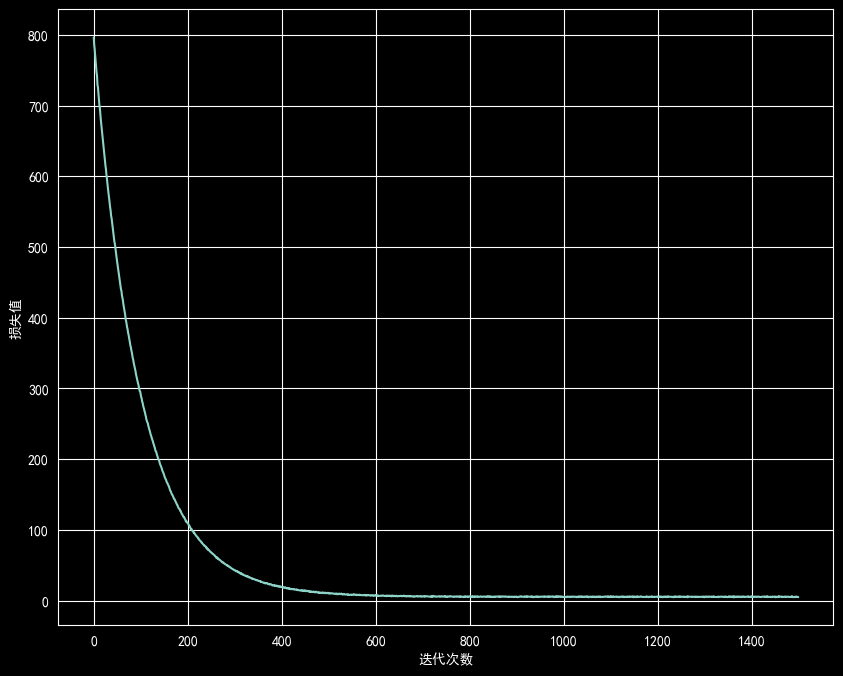

In [34]:
# 绘制损失下降曲线，用于训练过程调试
plt.plot(loss_hist)
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.show()

In [35]:
# 模型预测与准确率评估
y_train_pred = svm.predict(X_train)
print('在训练集上的准确率: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('在验证集上的准确率: %f' % (np.mean(y_val == y_val_pred), ))

在训练集上的准确率: 0.368102
在验证集上的准确率: 0.356000


In [36]:
# 网格搜索超参数：遍历学习率与正则化强度组合，基于验证集准确率筛选最优配置
# 小迭代数用于快速调试，确认逻辑后可增大迭代数提升最终效果
learning_rates = [1e-7, 5e-5]           # 2 个学习率
regularization_strengths = [2.5e4, 5e4] # 2 个正则化
# 结果是字典映射的元组
results = {}
best_val = -1   # 最高的准确率.
best_svm = None # 得到最高准确率的 LinearSVM 对象.
# 遍历所有超参数组合：学习率 × 正则化强度
for lr in learning_rates:
    for reg in regularization_strengths:
        # 1. 初始化一个新的 LinearSVM 模型
        svm = LinearSVM()
        # 2. 用训练集训练这个 SVM（用较小的 num_iters 先验证代码，之后可改大）
        loss_hist = svm.train(X_train, y_train, learning_rate=lr, reg=reg, num_iters=2000, batch_size=200, verbose=False)
        # 3. 在训练集上做预测，计算训练集准确率
        y_train_pred = svm.predict(X_train)
        train_acc = np.mean(y_train == y_train_pred)  # 正确预测数 / 总样本数
        # 4. 在验证集上做预测，计算验证集准确率
        y_val_pred = svm.predict(X_val)
        val_acc = np.mean(y_val == y_val_pred)
        # 5. 把当前超参数组合的结果存入字典             # (lr, reg) 是一个元组（tuple），作为字典 results 的键（key）
        results[(lr, reg)] = (train_acc, val_acc)  # (train_acc, val_acc) 是一个元组，作为这个键对应的值（value）
        # 6. 如果当前验证集准确率更高，更新最佳记录
        if val_acc > best_val:
            best_val = val_acc
            best_svm = svm
# 打印结果
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('学习率 %e 正则化强度 %e 训练集准确率: %f 验证集准确率: %f' % (lr, reg, train_accuracy, val_accuracy))

print('交叉验证中在验证集上得到的最好的准确率: %f' % best_val)

学习率 1.000000e-07 正则化强度 2.500000e+04 训练集准确率: 0.367980 验证集准确率: 0.373000
学习率 1.000000e-07 正则化强度 5.000000e+04 训练集准确率: 0.353878 验证集准确率: 0.361000
学习率 5.000000e-05 正则化强度 2.500000e+04 训练集准确率: 0.100265 验证集准确率: 0.087000
学习率 5.000000e-05 正则化强度 5.000000e+04 训练集准确率: 0.100265 验证集准确率: 0.087000
交叉验证中在验证集上得到的最好的准确率: 0.373000


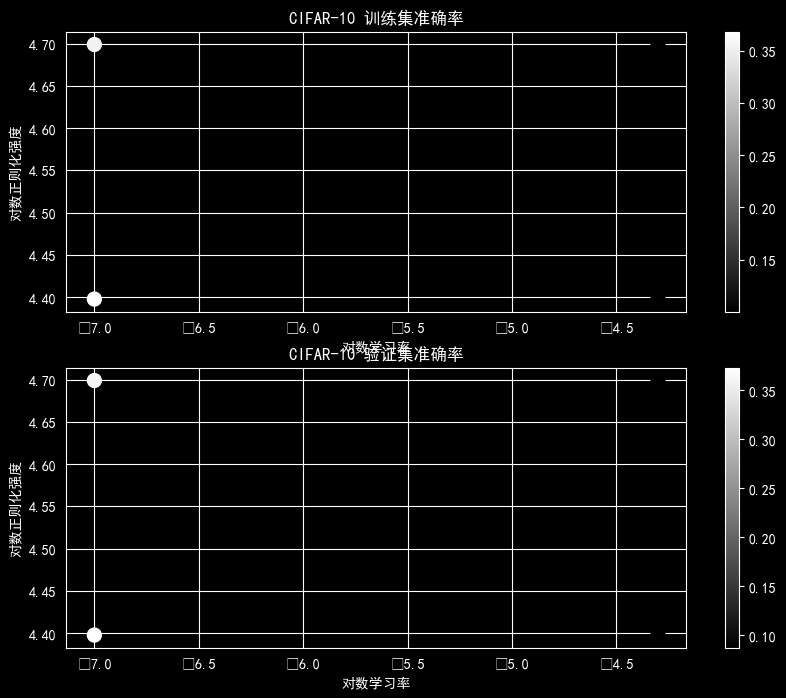

In [37]:
#可视化交叉验证结果
import math
x_scatter = [math.log10(x[0]) for x in results]  # 生成 x 轴坐标（学习率的对数）  遍历字典的所有键 x，取每个键的第0个元素x[0] → 就是学习率 lr.对每个学习率取log10()，转成对数刻度
y_scatter = [math.log10(x[1]) for x in results]  # 生成 y 轴坐标（正则化的对数）
# 为什么要取 log10()? 超参数是数量级跨度很大的小数/大数，直接用原始值画图，点会挤在坐标轴两端，看不出规律. 取 log10() 后，数量级差异被均匀拉开，方便观察不同超参数组合对准确率的影响
marker_size = 100     # 定义散点图中每个点的显示大小，数值越大，点在图上就越显眼

# 画训练集准确率 (看模型 “学进去多少”)
colors = [results[x][0] for x in results]  # results[x][0] → 训练集准确率 train_acc
plt.subplot(2, 1, 1)  # 创建一个 2行1列 的子图布局，并选中第 1 个子图（上面那张图）
plt.scatter(x_scatter, y_scatter, marker_size, c=colors)
plt.colorbar()        # 在图右侧显示一个颜色条，用来直观解释「颜色 → 训练集准确率」的对应关系，方便快速判断哪个点（超参数组合）准确率更高
plt.xlabel('对数学习率')
plt.ylabel('对数正则化强度')
plt.title('CIFAR-10 训练集准确率')

# 画验证集准确率 (看模型 “泛化能力如何”)
colors = [results[x][1] for x in results] # # results[x][1] → 验证集准确率 val_acc
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors)
plt.colorbar()
plt.xlabel('对数学习率')
plt.ylabel('对数正则化强度')
plt.title('CIFAR-10 验证集准确率')
plt.show()

In [38]:
# 在测试集上验证最好的SVM
y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('线性 SVM 在原始像素测试集上最终的大准确率: %f' % test_accuracy)

线性 SVM 在原始像素测试集上最终的大准确率: 0.368000


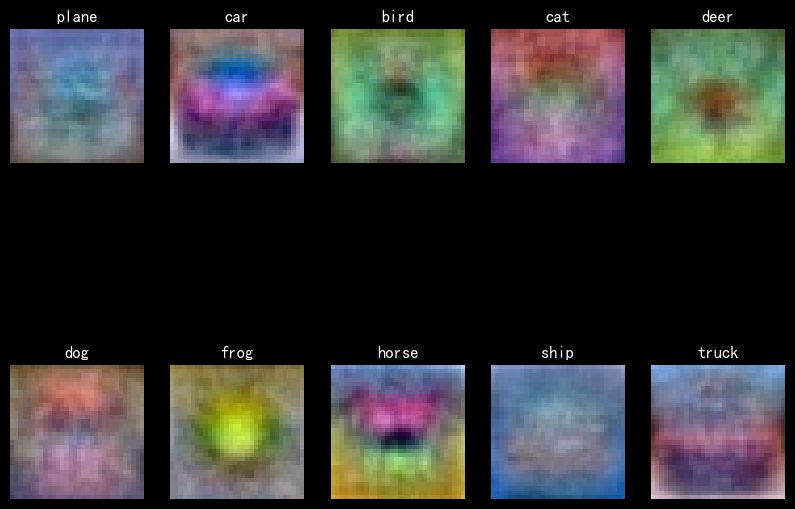

In [39]:
# 可视化每个分类的权重
w = best_svm.W[:-1,:]  # best_svm.W 权重矩阵(3073,10)  W[:-1, :]：切片去掉最后一行（偏置项），只保留纯像素权重
w = w.reshape(32, 32, 3, 10)  # 把权重 reshape 成图片格式
w_min, w_max = np.min(w), np.max(w)  # 计算所有权重的最小值和最大值，用于后续归一化到 0~255（图片像素范围）
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']  # 定义类别名称
for i in range(10):
    plt.subplot(2, 5, i + 1)  # 2行5列布局，第i+1个子图
    # 归一化到 0~255（图片像素范围）
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    '''
    w[:, :, :, i]：取出第 i 个类别的 32×32×3 权重图
    squeeze()：去掉冗余维度（如果有的话），保证是 (32,32,3) 形状
    归一化公式：wimg = 255 × w-w_min/w_max-w_min  (把权重从 [w_min, w_max] 线性映射到 [0, 255]，变成可显示的像素值)
    '''
    plt.imshow(wimg.astype('uint8'))  # 转成uint8类型(RGB 图片)并显示
    plt.axis('off')        # 隐藏坐标轴,只看图片本身
    plt.title(classes[i])  # 加上类别标题

### 权重可视化结果分析
训练得到的SVM分类权重可视化后呈现为模糊的彩色纹理，对应各类别的平均颜色特征模板，而非清晰的物体轮廓，原因如下：
1. **线性模型特性**：SVM为线性分类器，仅能学习像素与类别的线性映射关系，无法捕捉边缘、形状等复杂非线性视觉特征；
2. **权重的物理意义**：权重本质是类别样本的平均特征向量，反映数据集中该类别的典型颜色分布规律，而非具体物体结构；
3. **数据分布影响**：CIFAR-10同类样本的姿态、光照、背景差异较大，线性模型仅能学习到通用的平均颜色模式，因此呈现模糊的色块混合效果。